# Training neural network: Data augmentation

Tiếp nối bài thực hành trên lớp, bài tập về nhà này vẫn sử dụng MNIST là tập dữ liệu thử nghiệm. Mục tiêu là cải thiện hiệu suất của mô hình bằng các kỹ thuật Augmentation nhằm tăng cường số lượng dữ liệu

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from keras.datasets import mnist
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

%load_ext tensorboard
!rm -rf './graph/dropout/dropout=0.5,relu/'

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('Training image: ', x_train.shape)
print('Testing image: ', x_test.shape)
print('Training label: ', y_train.shape)
print('Testing label: ', y_test.shape)

Training image:  (60000, 28, 28)
Testing image:  (10000, 28, 28)
Training label:  (60000,)
Testing label:  (10000,)


In [ ]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255



In [ ]:
class SimpleModel(nn.Module):
    def __init__(self, dropout_rate):
        super(SimpleModel, self).__init__()
        self.dense_1 = nn.Linear(28*28, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.dense_2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Ensure input is flattened: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        x = self.dense_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.dense_2(x)
        output = F.log_softmax(x, dim=1)
        return output

# Check model parameter

In [ ]:
simple_model = SimpleModel(dropout_rate = 0.5).cuda()
for param in simple_model.parameters():
    if param.requires_grad:
        print('param autograd')
        break

input = torch.rand(1, 28, 28).cuda()
output = simple_model(input)  # type: torch.Tensor

model_parameters = filter(lambda p: p.requires_grad, simple_model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print('Number of parameter:', params)


param autograd
Number of parameter: 101770


## Tăng thêm dữ liệu (data augmentation) với thư viện imgaug

Trong phần thực hành này, chúng ta sẽ làm quen với các phương pháp tăng dữ liệu cho bài toán xử lý ảnh, các phương pháp này hoàn toàn có thể lập trình sử dụng thư viện numpy (vì bản chất của phương pháp là ta thao tác trên ma trận biểu diễn ảnh). Tuy nhiên, để việc lập trình được nhanh chóng, chúng ta sẽ làm quen với một thư viện rất mạnh mẽ, giúp ta nhanh chóng cài đặt nhiều phương pháp tăng dữ liệu hiệu quả khác nhau: thư viện imgaug

Để cài đặt imgaug, ta sử dụng lệnh:

pip install imgaug

pip install scikit-image --upgrade

In [ ]:
import sys
# Install imgaug and scikit-image with specific version constraints to avoid NumPy 2.0 conflicts
!{sys.executable} -m pip install imgaug "numpy<2.1.0" "scikit-image<0.26.0" --upgrade

  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached scikit_image-0.25.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
Using cached scikit_image-0.25.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (15.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.24.0
    Uninstalling scikit-image-0.24.0:
      Successfully uninstalled scikit-image-0.24.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompa

In [ ]:
# Bước 1: Hạ cấp NumPy để tương thích với imgaug
!pip install "numpy>=1.26.0,<2.0.0" "scikit-image<0.25.0" --force-reinstall

print('\n' + '='*50)
print('QUAN TRỌNG: Bạn PHẢI Restart session ngay bây giờ!')
print('Vào menu: Runtime -> Restart session')
print('='*50)

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_image-0.24.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2026.3.3-py3-none-any.whl.metadata (31 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scikit_image-0.24.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (15.0 MB)
Using cached imageio-2.37.3-py3-none-any.whl (31


QUAN TRỌNG: Bạn PHẢI Restart session ngay bây giờ!
Vào menu: Runtime -> Restart session


### Note on Compatibility
After downgrading NumPy to a version below 2.0, you may need to **Restart the Session** (Runtime > Restart session) for the changes to take effect before running the cells below.

### Note on Compatibility
After downgrading NumPy to a version below 2.0, you may need to **Restart the Session** (Runtime > Restart session) for the changes to take effect before running the cells below.

In [ ]:
# Bước 2: Sau khi Restart session, hãy chạy cell này
import numpy as np
print(f'Phiên bản NumPy hiện tại: {np.version.version}')

if np.version.version.startswith('1.'):
    from imgaug import augmenters as iaa
    print('Import thành công!')
else:
    print('CẢNH BÁO: NumPy vẫn là 2.x. Bạn chưa Restart session!')

Phiên bản NumPy hiện tại: 1.26.4
Import thành công!


Để tìm hiểu lần lượt các phương pháp, thử áp dụng trên ảnh cat.jpg trong thư mục bài thực hành:

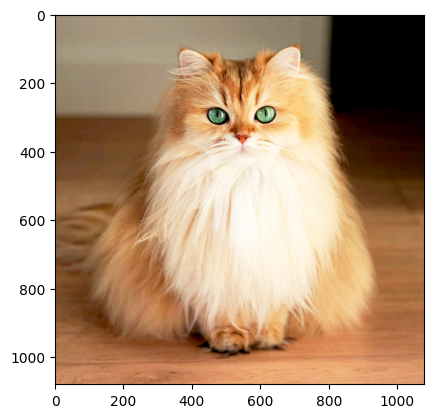

In [ ]:
import cv2
image = cv2.imread('cat.jpg')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

### Các phương pháp thường sử dụng

Các phương pháp hay được sử dụng nhất trong các bài toán xử lý ảnh có thể tham khảo tại: https://imgaug.readthedocs.io/en/latest/source/augmenters.html

1. CropAndPad: Cắt hoặc thêm các pixel vào ảnh.

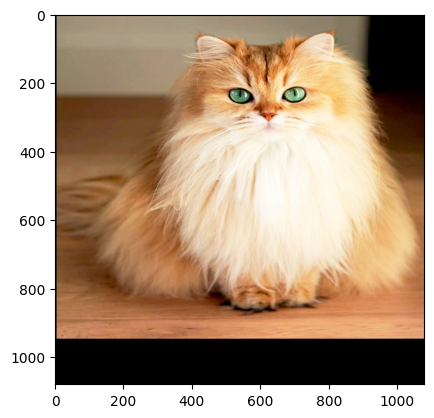

In [ ]:
crop_and_pad = iaa.CropAndPad(percent=(-0.25, 0.25))

plt.imshow(cv2.cvtColor(crop_and_pad.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

2. Flip: Flip left-right hoặc Flip up-down một số ảnh trong tập ảnh truyền vào

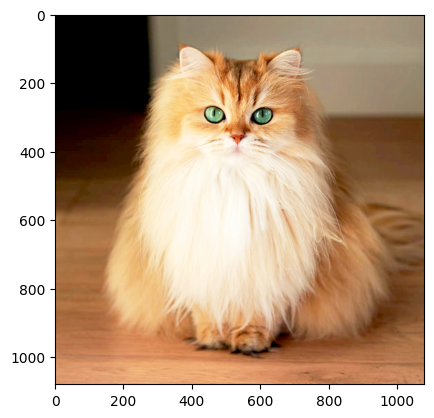

In [ ]:
flip_lr = iaa.Fliplr(1.0)

plt.imshow(cv2.cvtColor(flip_lr.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

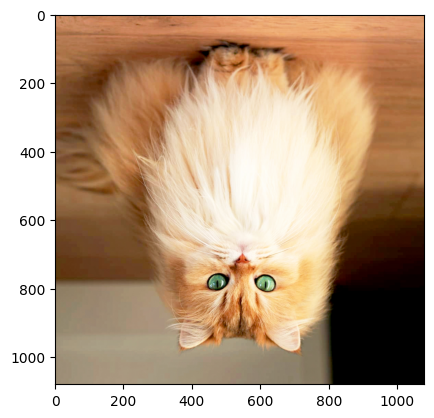

In [ ]:
flip_ud = iaa.Flipud(1.0)

plt.imshow(cv2.cvtColor(flip_ud.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

- Affine: Các phép biến đổi affine như scale, rotate, translate:

In [ ]:
affine = iaa.Affine(scale=(0.5, 1.5), rotate=(-15, 15), translate_percent=(-0.2, 0.2))

plt.imshow(cv2.cvtColor(affine.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

KeyboardInterrupt: 

- Blur: Sử dụng các bộ lọc Gaussian hoặc Mean:

In [ ]:
avg_blur = iaa.AverageBlur(k=(11, 31))
gauss_blur = iaa.GaussianBlur(sigma=(5, 15))

plt.imshow(cv2.cvtColor(avg_blur.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv2.cvtColor(gauss_blur.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

- Dropout: Biến đổi ngẫu nhiên một phần ảnh thành các pixel đen

In [ ]:
dropout = iaa.Dropout(p=(0, 0.2))

plt.imshow(cv2.cvtColor(dropout.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

### Kết hợp nhiều augmenter

Trong thực tế, có nhiều chiến lược trong việc thực hiện các augmenter khác nhau, thư viện imgaug cũng hỗ trợ một số hàm để thực hiện công việc này:

- Sequential: Áp dụng các augmenter lần lượt theo thứ tự truyền vào:

In [ ]:
aug = iaa.Sequential([
    iaa.Affine(translate_px={"x":(-40, 40)}),
    iaa.AdditiveGaussianNoise(scale=0.1*255)
])

plt.imshow(cv2.cvtColor(aug.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

- SomeOf: Áp dụng ngẫu nhiên một vài augmenter trong list các augmenter:

In [ ]:
aug = iaa.SomeOf(2, [
    iaa.Affine(rotate=45),
    iaa.AdditiveGaussianNoise(scale=0.2*255),
    iaa.Add(50, per_channel=True),
    iaa.Sharpen(alpha=0.5)
])

plt.imshow(cv2.cvtColor(aug.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

- Sometimes: Áp dụng augmenter với xác suất p:

In [ ]:
aug = iaa.Sometimes(0.5, iaa.GaussianBlur(sigma=20.0))

plt.imshow(cv2.cvtColor(aug.augment_image(image), cv2.COLOR_BGR2RGB))
plt.show()

### Kết hợp cùng thư viện Keras

Bây giờ chúng ta sẽ sử dụng các augmenter đã viết để thực hiện augment image trong quá trình huấn luyện mạng với thư viện Keras.

- Bước 1: Khởi tạo Augmenter:

In [ ]:
aug = iaa.Dropout(p=(0, 0.002))

- Bước 2: Xây dựng generator:

In [ ]:
class Generator(Dataset):
    def __init__(self, images, labels, augmenter=None):
        self.images = images
        self.labels = labels
        self.augmenter = augmenter

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.augmenter is not None:
            # imgaug expects (N, H, W) or (H, W, C)
            image = self.augmenter.augment_image(image)

        # Convert to tensor and add channel dimension (C, H, W)
        image_tensor = torch.from_numpy(image).float().unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return image_tensor, label_tensor

In [ ]:
# Initialize training data with the 'aug' defined earlier
training_data = Generator(x_train, y_train, augmenter=aug)
train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)

In [ ]:
# Test data should NOT be augmented
test_data = Generator(x_test, y_test, augmenter=None)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

Quan sát thử kết quả của generator bên trên:

In [ ]:
for (batch_idx, target_tuple) in enumerate(train_dataloader):
    print(target_tuple[0].shape)
    for i in range(32):
        plt.subplot(4, 8, i + 1), plt.imshow(target_tuple[0][i], cmap='gray')
    plt.show()
    break

- Bước 3: Train model với fit_generator:

In [ ]:
use_cuda = torch.cuda.is_available()  #GPU cuda
best_loss = float('inf')

model = SimpleModel(dropout_rate = 0.5)

optimizer = torch.optim.Adadelta(model.parameters())

if use_cuda:
    model = torch.nn.parallel.DataParallel(model.cuda())   # , device_ids=[0, 1, 2, 3]
    torch.backends.cudnn.benchmark = True



In [ ]:
def train(epoch):
    print('\n ############################# Train phase, Epoch: {} #############################'.format(epoch))
    model.train()
    train_loss = 0

    print('\nLearning rate at this epoch is: ', optimizer.param_groups[0]['lr'], '\n')

    for batch_idx, (images, labels) in enumerate(train_dataloader):
        if use_cuda:
            images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()
        output = model(images)
        loss = F.nll_loss(output, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        if batch_idx % 500 == 0:
            print('Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(images), len(train_dataloader.dataset),
                100. * batch_idx / len(train_dataloader), loss.item()))

    global best_loss
    train_loss /= len(train_dataloader)
    if train_loss < best_loss:
        best_loss = train_loss
        save_path = 'checkpoints/model_best.pth'
    else:
        save_path = f'checkpoints/model_epoch_{epoch}.pth'

    os.makedirs('checkpoints', exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f'Saved model to {save_path}')

In [ ]:
def test(epoch):
    print('\n ############################# Test phase, Epoch: {} #############################'.format(epoch))
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            if use_cuda:
                images, labels = images.cuda(), labels.cuda()

            output = model(images)
            test_loss += F.nll_loss(output, labels, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()

    test_loss /= len(test_dataloader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_dataloader.dataset),
        100. * correct / len(test_dataloader.dataset)))

In [ ]:
no_epoch = 5
for epoch in range(no_epoch):
    train(epoch)
    test(epoch)

# Detailed Insights on Data Augmentation

Following the implementation of various augmentation techniques using `imgaug`, here are the detailed insights regarding their impact on the training process:

### 1. Robustness to Spatial Variance
By using **CropAndPad**, **Fliplr**, and **Affine** transformations (scale, rotate, translate), the model learns that a digit's identity is independent of its exact placement or orientation. In MNIST, while numbers are generally centered, real-world inputs often vary, and these augmentations prepare the model for that variance.

### 2. Denoising and Structural Learning
Applying **AverageBlur** and **GaussianBlur** simulates lower-quality imaging. This forces the neural network to identify the 'skeleton' or the core topology of the digit rather than relying on sharp, high-frequency edges that might not be present in all test cases.

### 3. Regularization through Input Dropout
Using `iaa.Dropout` at the image level is a powerful form of regularization. By randomly zeroing out pixels, the model is forced to find redundant features to identify a digit (e.g., recognizing an '8' even if part of a loop is missing). This prevents the model from 'memorizing' specific pixel configurations.

### 4. Integration with Training Pipelines
The use of the `Generator(Dataset)` class ensures that augmentations are applied **on-the-fly**. This means the model effectively sees a 'new' version of the training set in every epoch, which is significantly more effective than static data augmentation for preventing overfitting on small-to-medium datasets like MNIST.

# Final Insights and Summary

Based on the completed exercises, here are the key takeaways for using Data Augmentation in Deep Learning:

1. **Improved Generalization**: By using `Affine`, `CropAndPad`, and `Fliplr`, we ensure the model does not overfit to the specific orientation or position of digits in the training set.
2. **Noise Resilience**: Techniques like `GaussianBlur` and `AverageBlur` help the model focus on the structural shape of the digit rather than pixel-level noise, making it more robust to real-world input variations.
3. **Efficient Regularization**: `iaa.Dropout` at the image level serves as an additional layer of regularization, complementary to the Dropout layers inside the neural network architecture.
4. **Dynamic Data Generation**: Integrating these augmenters into a `DataLoader` (via the `Generator` class) allows for 'on-the-fly' augmentation, providing the model with fresh variations in every epoch without increasing storage requirements.